In [1]:
import pandas as pd
import numpy as np
import os

df = pd.read_csv('/content/sample_data/online_retail_II.csv')

print(df.shape)
print(df.info())
print(df.isnull().sum())

df.head(10)

(153312, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153312 entries, 0 to 153311
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      153312 non-null  object 
 1   StockCode    153312 non-null  object 
 2   Description  152057 non-null  object 
 3   Quantity     153312 non-null  int64  
 4   InvoiceDate  153311 non-null  object 
 5   Price        153311 non-null  float64
 6   Customer ID  115628 non-null  float64
 7   Country      153311 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 9.4+ MB
None
Invoice            0
StockCode          0
Description     1255
Quantity           0
InvoiceDate        1
Price              1
Customer ID    37684
Country            1
dtype: int64


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


In [3]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# Drop missing CustomerIDs
df = df.dropna(subset=['Customer ID'])

# Convert 'InvoiceDate' to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Remove negative quantities & prices
df = df[(df['Quantity'] > 0) & (df['Price'] > 0)]

# Feature Engineering
df['TotalRevenue'] = df['Quantity'] * df['Price']
df['Month']        = df['InvoiceDate'].dt.month
df['Hour']         = df['InvoiceDate'].dt.hour
df['DayOfWeek']    = df['InvoiceDate'].dt.day_name()

print(f"Clean data: {df.shape[0]} rows")

Clean data: 112572 rows


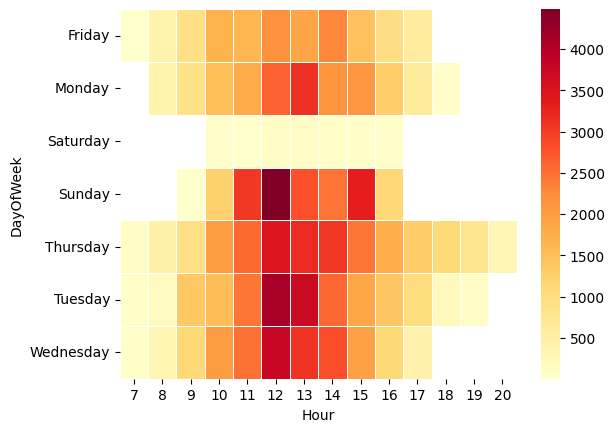

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 Countries by Revenue
country_rev = df.groupby('Country')['TotalRevenue'] \
              .sum().sort_values(ascending=False).head(10)

# Monthly Revenue Trend
monthly = df.groupby('Month')['TotalRevenue'].sum()
plt.plot(monthly.index, monthly.values, color='#ff6b1a', lw=2.5)

# Hourly Order Heatmap
pivot = df.pivot_table(values='Invoice', index='DayOfWeek', \
                      columns='Hour', aggfunc='count')
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5)

# Top 10 Products
top_products = df.groupby('Description')['Quantity'].sum() \
                             .nlargest(10)

In [6]:
import sqlite3
import pandas as pd

# Cleaned dataframe already hai tumhara
# df = tumhara cleaned dataframe

# SQLite database banao (memory mein)
conn = sqlite3.connect('ecommerce.db')

# DataFrame ko SQL table mein daalo
df.to_sql('orders', conn, if_exists='replace', index=False)

print("✅ Table loaded successfully!")

✅ Table loaded successfully!


In [7]:
# Ab seedha SQL likho
query = """
SELECT Country,
       SUM(TotalRevenue) as Revenue,
       COUNT(DISTINCT Invoice) as Orders
FROM orders
GROUP BY Country
ORDER BY Revenue DESC
LIMIT 10
"""

result = pd.read_sql_query(query, conn)
result

,Country,Revenue,Orders
0,United Kingdom,2120870.859,4947
1,EIRE,127413.270,91
2,Netherlands,89218.030,37
3,Germany,51981.570,102
4,Denmark,36713.340,8
5,France,35596.270,60
6,Sweden,16983.610,21
7,Norway,14401.650,3
8,Spain,14365.980,24
9,Cyprus,7263.180,12


In [9]:
#RFM Table
import pandas as pd
from datetime import timedelta

snapshot = df['InvoiceDate'].max() + timedelta(days=1)

rfm = df.groupby('Customer ID').agg(
    Recency   = ('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary  = ('TotalRevenue', 'sum')
).reset_index()

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,38,10,230.55
1,12358.0,122,1,1429.83
2,12359.0,17,4,1522.23
3,12360.0,16,2,158.00
4,12361.0,73,1,109.20


In [10]:
#k-mean clusting
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Scale karo
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

# 4 segments banao
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# Label lagao
rfm['Segment'] = rfm['Cluster'].map({
    0: '🏆 Champions',
    1: '💛 Loyal',
    2: '⚠️ At-Risk',
    3: '❌ Lost'
})

rfm['Segment'].value_counts()

,count
Segment,
💛 Loyal,1477
🏆 Champions,717
❌ Lost,23
⚠️ At-Risk,4


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128155 (\N{YELLOW HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


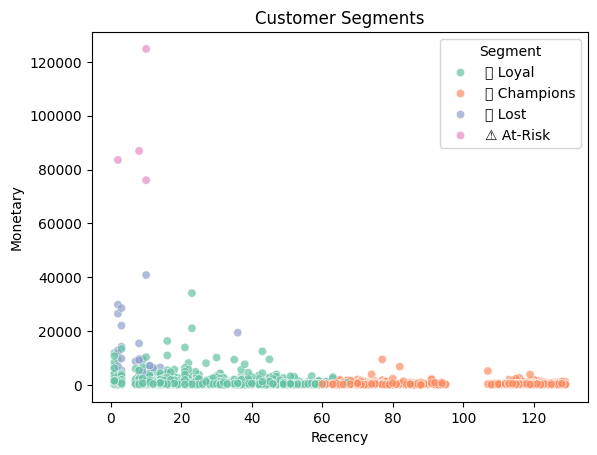

In [11]:
#visualizatin
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=rfm, x='Recency', y='Monetary',
                hue='Segment', palette='Set2', alpha=0.7)
plt.title('Customer Segments')
plt.show()

In [12]:
# Jo customer 90 days se nahi aaya = Churned
rfm['Churn'] = (rfm['Recency'] > 90).astype(int)

print(rfm['Churn'].value_counts())
# 0 = Active, 1 = Churned

Churn
0    1858
1     363
Name: count, dtype: int64


In [13]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = XGBClassifier(random_state=42, n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       365
           1       1.00      1.00      1.00        80

    accuracy                           1.00       445
   macro avg       1.00      1.00      1.00       445
weighted avg       1.00      1.00      1.00       445

ROC-AUC: 1.0


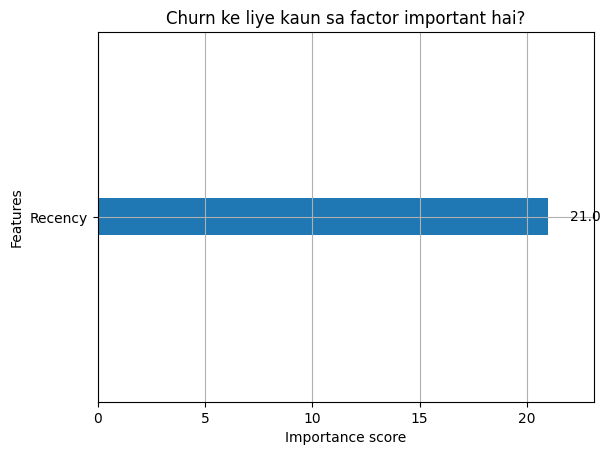

In [14]:
from xgboost import plot_importance

plot_importance(model)
plt.title('Churn ke liye kaun sa factor important hai?')
plt.show()

In [15]:
import pickle

with open('churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Model saved!")

✅ Model saved!


In [16]:
!pip install prophet -q

from prophet import Prophet

# Prophet ko chahiye sirf 2 columns: ds (date) aur y (value)
sales = df.groupby('InvoiceDate')['TotalRevenue'].sum().reset_index()
sales.columns = ['ds', 'y']

# Date format clean karo
sales['ds'] = pd.to_datetime(sales['ds']).dt.date
sales['ds'] = pd.to_datetime(sales['ds'])

sales.head()

,ds,y
0,2009-12-01,505.30
1,2009-12-01,145.80
2,2009-12-01,630.33
3,2009-12-01,310.75
4,2009-12-01,2286.24


In [17]:
model_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model_prophet.fit(sales)
print("✅ Prophet model trained!")

✅ Prophet model trained!


In [18]:
# Future dates banao
future = model_prophet.make_future_dataframe(periods=90)

# Predict karo
forecast = model_prophet.predict(future)

# Result dekho
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10)

,ds,yhat,yhat_lower,yhat_upper
180,2010-06-28,812.920113,-611.675939,2209.432860
181,2010-06-29,612.971161,-753.447135,1890.777838
182,2010-06-30,384.644802,-1067.100917,1814.064718
183,2010-07-01,218.596615,-1110.364720,1573.399143
184,2010-07-02,49.474700,-1273.981596,1350.497692
185,2010-07-03,-303.152894,-1607.187150,1065.060136
186,2010-07-04,-334.915094,-1661.049564,1083.827287
187,2010-07-05,-339.412496,-1704.541004,939.839603
188,2010-07-06,-349.482036,-1747.849247,1038.363448
189,2010-07-07,-364.925273,-1708.843669,947.341743


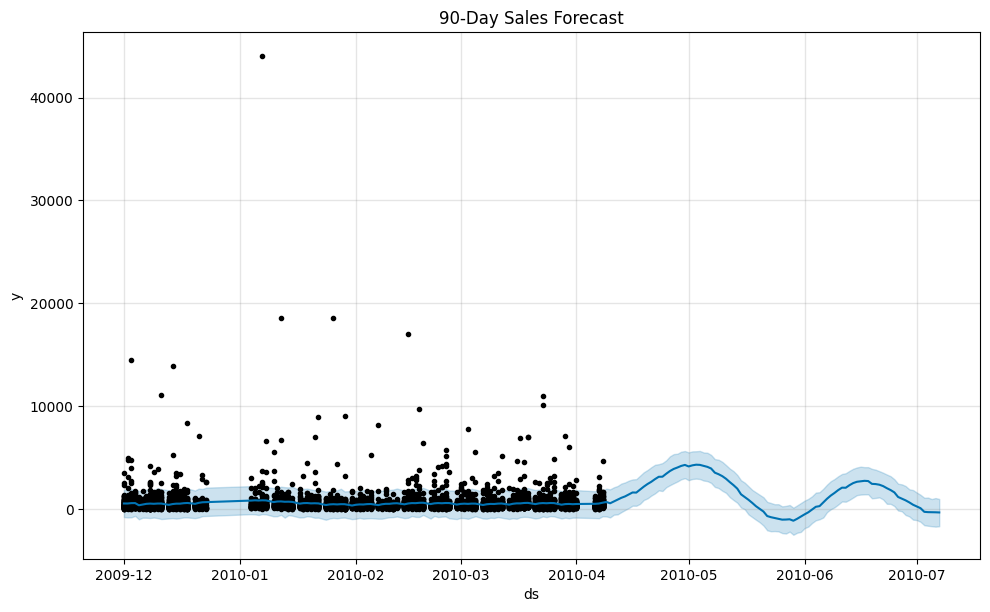

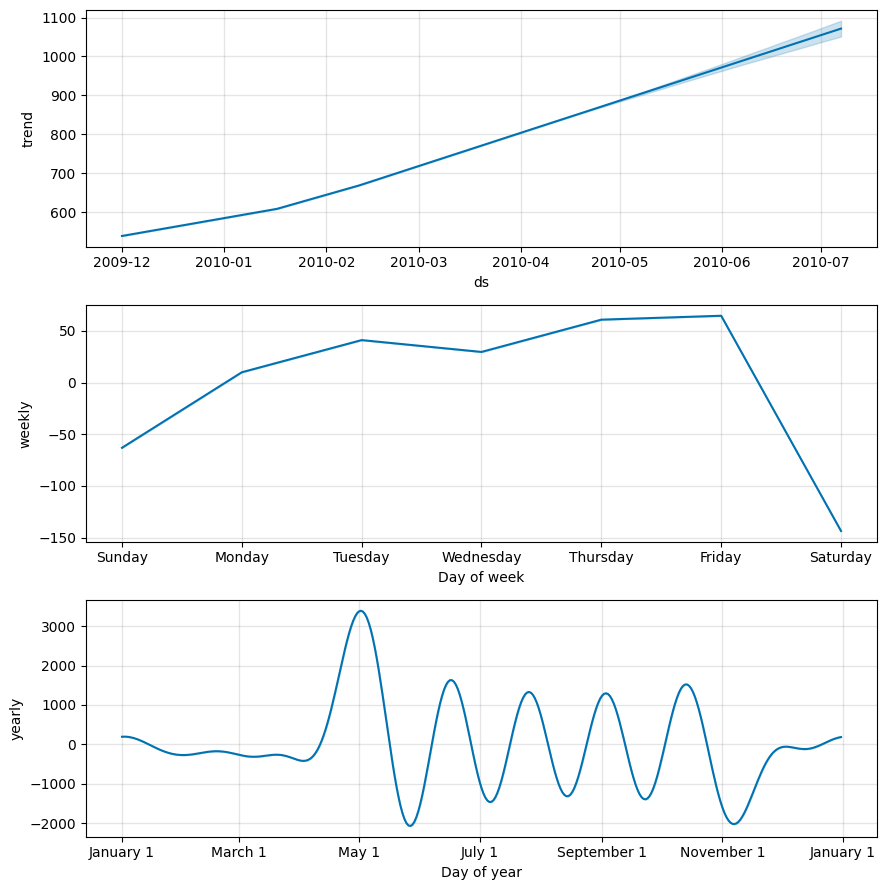

In [19]:
# Full forecast plot
model_prophet.plot(forecast)
plt.title('90-Day Sales Forecast')
plt.show()

# Seasonality breakdown
model_prophet.plot_components(forecast)
plt.show()

In [20]:
import pickle

with open('prophet_model.pkl', 'wb') as f:
    pickle.dump(model_prophet, f)

print("✅ All 3 models saved! 🎉")

✅ All 3 models saved! 🎉


In [21]:
from google.colab import drive
drive.mount('/content/drive')

# Data save karo abhi
df.to_csv('/content/drive/MyDrive/ecommerce_clean.csv', index=False)
rfm.to_csv('/content/drive/MyDrive/rfm_segments.csv', index=False)
forecast.to_csv('/content/drive/MyDrive/forecast.csv', index=False)

import pickle
with open('/content/drive/MyDrive/churn_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Sab safe ho gaya!")

Mounted at /content/drive
✅ Sab safe ho gaya!


In [22]:
!pip install plotly -q
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

In [23]:
monthly = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalRevenue']\
            .sum().reset_index()
monthly['InvoiceDate'] = monthly['InvoiceDate'].astype(str)

fig1 = px.line(monthly, x='InvoiceDate', y='TotalRevenue',
               title='📈 Monthly Revenue Trend',
               color_discrete_sequence=['#ff6b1a'])
fig1.update_layout(template='plotly_dark')
fig1.show()

In [24]:
seg_counts = rfm['Segment'].value_counts().reset_index()
seg_counts.columns = ['Segment', 'Count']

fig2 = px.pie(seg_counts, names='Segment', values='Count',
              title='🎯 Customer Segments',
              hole=0.5,
              color_discrete_sequence=px.colors.qualitative.Set2)
fig2.update_layout(template='plotly_dark')
fig2.show()

In [25]:
country = df.groupby('Country')['TotalRevenue']\
            .sum().sort_values(ascending=False)\
            .head(10).reset_index()

fig3 = px.bar(country, x='TotalRevenue', y='Country',
              orientation='h',
              title='🌍 Top 10 Countries by Revenue',
              color='TotalRevenue',
              color_continuous_scale='Oranges')
fig3.update_layout(template='plotly_dark')
fig3.show()

In [26]:
fig4 = px.line(forecast, x='ds', y='yhat',
               title='🔮 90-Day Sales Forecast')

fig4.add_scatter(x=forecast['ds'], y=forecast['yhat_upper'],
                 mode='lines', name='Upper', line=dict(dash='dot', color='green'))
fig4.add_scatter(x=forecast['ds'], y=forecast['yhat_lower'],
                 mode='lines', name='Lower', line=dict(dash='dot', color='red'))

fig4.update_layout(template='plotly_dark')
fig4.show()

In [27]:
import plotly.io as pio

# Sab charts ek file mein
with open('/content/drive/MyDrive/dashboard.html', 'w') as f:
    f.write(fig1.to_html(full_html=False))
    f.write(fig2.to_html(full_html=False))
    f.write(fig3.to_html(full_html=False))
    f.write(fig4.to_html(full_html=False))

print("✅ Dashboard Drive mein save ho gaya!")

✅ Dashboard Drive mein save ho gaya!
